In [643]:
# COMP90049 Introduction to Machine Learning - Assignment 2 
# Guangheng (Jack) Tong 1129548

from ucimlrepo import fetch_ucirepo 
import pandas as pd
  
# fetch dataset 
optical_recognition_of_handwritten_digits = fetch_ucirepo(id=80) 
  
# data (as pandas dataframes) 
X = optical_recognition_of_handwritten_digits.data.features 
y = optical_recognition_of_handwritten_digits.data.targets 

# Check the shapes
print("Dataset shape:", X.shape)  # Should be (5620, 64)
print("Labels shape:", y.shape)  # Should be (5620, 1)

Dataset shape: (5620, 64)
Labels shape: (5620, 1)


In [644]:
import numpy as np

# Check how the digits are distributed?
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

{0: 554, 1: 571, 2: 557, 3: 572, 4: 568, 5: 558, 6: 558, 7: 566, 8: 554, 9: 562}


In [645]:
# Preprocessing 1 - Normalize pixel values to range [0, 1]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Check the min and max to confirm the scaling worked
print("Min value after normalization:", X_normalized.min())  # Should be 0
print("Max value after normalization:", X_normalized.max())  # Should be 1

Min value after normalization: 0.0
Max value after normalization: 1.0


In [646]:
# Preprocessing 2 - Check and Remove Duplicates
# Convert to DataFrame for easier duplicate handling
df = pd.DataFrame(X_normalized)
df['label'] = y

# Check for duplicates in features (excluding label)
print("Number of duplicates:", df.duplicated(subset=df.columns[:-1]).sum())

# Remove duplicates, keeping the first occurrence
df = df.drop_duplicates(subset=df.columns[:-1], keep='first')

# Update X and y
X_normalized = df.iloc[:, :-1].values
y = df['label'].values

print("New dataset shape after duplicate removal:", X_normalized.shape)

# Since there is no duplicate we do not need to remove anything.

Number of duplicates: 0
New dataset shape after duplicate removal: (5620, 64)


In [647]:
# Reshape the Data for Feature Construction 
n_samples = X_normalized.shape[0]
X_reshaped = X_normalized.reshape(n_samples, 8, 8)

print("Reshaped data shape:", X_reshaped.shape)  # Should be (5620, 8, 8)

Reshaped data shape: (5620, 8, 8)


In [648]:
# Feature Construction
# Row sums
row_sums = X_reshaped.sum(axis=2)

# Column sums
col_sums = X_reshaped.sum(axis=1)

# Total sum per sample (for normalization in weighted averages)
total_sum = X_normalized.sum(axis=1, keepdims=True)
total_sum[total_sum == 0] = 1  # Avoid division by zero (rare case)

# Indices for weighting
row_indices = np.arange(8).reshape(1, 8)
col_indices = np.arange(8).reshape(1, 8)

# Mean row index
mean_row = (row_sums * row_indices).sum(axis=1, keepdims=True) / total_sum

# Mean column index
mean_col = (col_sums * col_indices).sum(axis=1, keepdims=True) / total_sum

# Variance of row indices
var_row = (((row_indices - mean_row) ** 2) * row_sums).sum(axis=1, keepdims=True) / total_sum

# Variance of column indices
var_col = (((col_indices - mean_col) ** 2) * col_sums).sum(axis=1, keepdims=True) / total_sum

# High-intensity pixel count
high_intensity_count = (X_normalized > 0.5).sum(axis=1, keepdims=True)

# Left-right symmetry score
lr_flipped = np.fliplr(X_reshaped)
lr_diff = np.abs(X_reshaped - lr_flipped)
lr_symmetry = lr_diff[:, :, 0:4].sum(axis=(1, 2))[:, np.newaxis]

# Top-bottom symmetry score
tb_flipped = np.flipud(X_reshaped)
tb_diff = np.abs(X_reshaped - tb_flipped)
tb_symmetry = tb_diff[:, 0:4, :].sum(axis=(1, 2))[:, np.newaxis]

# Combine new features
new_features = np.hstack([row_sums, col_sums, mean_row, mean_col, var_row, var_col, 
                          high_intensity_count, lr_symmetry, tb_symmetry])

print("row_sums shape:", row_sums.shape)  # Should be (5620, 8)
print("col_sums shape:", col_sums.shape)  # Should be (5620, 8)
print("mean_row shape:", mean_row.shape)  # Should be (5620, 1)
print("mean_col shape:", mean_col.shape)  # Should be (5620, 1)
print("var_row shape:", var_row.shape)  # Should be (5620, 1)
print("var_col shape:", var_col.shape)  # Should be (5620, 1)
print("high_intensity_count shape:", high_intensity_count.shape)  # Should be (5620, 1)
print("lr_symmetry shape:", lr_symmetry.shape)  # Should be (5620, 1)
print("tb_symmetry shape:", tb_symmetry.shape)  # Should be (5620, 1)
print("New features shape:", new_features.shape)  # Should be (5620, 23)

row_sums shape: (5620, 8)
col_sums shape: (5620, 8)
mean_row shape: (5620, 1)
mean_col shape: (5620, 1)
var_row shape: (5620, 1)
var_col shape: (5620, 1)
high_intensity_count shape: (5620, 1)
lr_symmetry shape: (5620, 1)
tb_symmetry shape: (5620, 1)
New features shape: (5620, 23)


In [649]:
# Combine original and new features
X_final = np.hstack([X_normalized, new_features])

print("Final feature matrix shape:", X_final.shape)  # Should be (5620, 87)

Final feature matrix shape: (5620, 87)


In [650]:
# Implement the Three Machine Learning Algorithms - Libraries
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, GridSearchCV, learning_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [651]:
# Define the Nested Cross-Validation Function
# Compute accuracy, precision, recall, F1-score, and an overall confusion matrix.

def nested_cv(X, y, pipeline, param_grid, outer_cv, inner_cv):
    scores = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    overall_cm = np.zeros((10, 10))  # 10x10 matrix for 10 digit classes (0-9)
    
    for train_idx, test_idx in outer_cv.split(X, y):
        # Split data into training and test sets for this outer fold
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Perform hyperparameter tuning with inner CV on the training set
        grid_search = GridSearchCV(pipeline, param_grid, cv=inner_cv, scoring='accuracy')
        grid_search.fit(X_train, y_train)
        
        # Get the best model from inner CV
        best_model = grid_search.best_estimator_
        
        # Make predictions on the test set
        y_pred = best_model.predict(X_test)
        
        # Compute and store metrics
        scores['accuracy'].append(accuracy_score(y_test, y_pred))
        scores['precision'].append(precision_score(y_test, y_pred, average='macro'))
        scores['recall'].append(recall_score(y_test, y_pred, average='macro'))
        scores['f1'].append(f1_score(y_test, y_pred, average='macro'))
        
        # Compute and add to the overall confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        overall_cm += cm
    
    # Calculate mean and standard deviation of scores across folds
    mean_scores = {metric: np.mean(scores[metric]) for metric in scores}
    std_scores = {metric: np.std(scores[metric]) for metric in scores}
    
    return mean_scores, std_scores, overall_cm

In [652]:
# Define the Learning Curve Function

# Define training sizes for learning curves (10% to 100% of data)
train_sizes = np.linspace(0.1, 1.0, 10)

# Function to plot learning curves
def plot_learning_curve(pipeline, X, y, train_sizes, cv, title):
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y, train_sizes=train_sizes, cv=cv, scoring='accuracy', n_jobs=-1
    )
    
    # Compute mean and standard deviation
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_mean, label='Training Accuracy', marker='o')
    plt.plot(train_sizes, val_mean, label='Validation Accuracy', marker='o')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.grid()
    plt.show()

In [653]:
# Set Up Cross-Validation Objects
# Use 5-fold outer cross-validation to evaluate model performance.
# Use 3-fold inner cross-validation to tune hyperparameters.
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)  # Fixes the random seed for reproducibility.
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)  # Fixes the random seed for reproducibility.

Naive Bayes Results:
Accuracy: 0.9345 (±0.0096)
Precision: 0.9367 (±0.0096)
Recall: 0.9346 (±0.0092)
F1: 0.9347 (±0.0094)
Overall Confusion Matrix:
 [[545.   1.   0.   0.   5.   0.   1.   0.   2.   0.]
 [  0. 484.  23.   1.   0.   0.   4.   1.  31.  27.]
 [  0.   5. 530.   4.   0.   0.   0.   1.  10.   7.]
 [  0.   1.   4. 532.   0.   6.   0.   5.  11.  13.]
 [  0.   1.   0.   0. 526.   1.   5.  16.   9.  10.]
 [  0.   0.   0.   8.   0. 503.   0.   4.   4.  39.]
 [  0.   6.   0.   0.   2.   0. 545.   0.   5.   0.]
 [  0.   1.   0.   1.   0.   6.   0. 551.   2.   5.]
 [  0.  19.   0.   1.   1.   6.   0.   1. 521.   5.]
 [  0.   6.   0.  15.   3.   2.   0.  14.   7. 515.]]
Best Naive Bayes Parameters: {'clf__var_smoothing': 0.001}


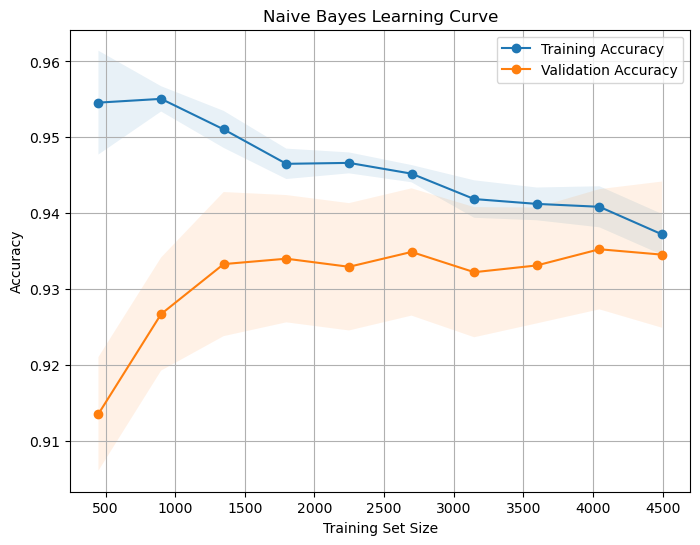

In [655]:
# Implement Naive Bayes
# Define the pipeline for Naive Bayes
nb_pipeline = Pipeline([('clf', GaussianNB())])

# Define the hyperparameter grid
nb_param_grid = {'clf__var_smoothing': [0.0001, 0.001, 0.01]}

# Perform nested cross-validation
nb_mean_scores, nb_std_scores, nb_cm = nested_cv(X_final, y, nb_pipeline, nb_param_grid, outer_cv, inner_cv)

# Print results
print("Naive Bayes Results:")
for metric in nb_mean_scores:
    print(f"{metric.capitalize()}: {nb_mean_scores[metric]:.4f} (±{nb_std_scores[metric]:.4f})")
print("Overall Confusion Matrix:\n", nb_cm)

# Plot the learning curves
nb_grid_search = GridSearchCV(nb_pipeline, nb_param_grid, cv=inner_cv, scoring='accuracy')
nb_grid_search.fit(X_final, y)
best_nb_pipeline = nb_grid_search.best_estimator_

print("Best Naive Bayes Parameters:", nb_grid_search.best_params_)
plot_learning_curve(best_nb_pipeline, X_final, y, train_sizes, outer_cv, 'Naive Bayes Learning Curve')

SVM Results:
Accuracy: 0.9888 (±0.0022)
Precision: 0.9890 (±0.0019)
Recall: 0.9888 (±0.0023)
F1: 0.9888 (±0.0021)
Overall Confusion Matrix:
 [[552.   0.   1.   0.   0.   0.   1.   0.   0.   0.]
 [  0. 568.   0.   0.   2.   0.   0.   1.   0.   0.]
 [  0.   0. 554.   0.   0.   0.   0.   0.   2.   1.]
 [  0.   0.   0. 563.   1.   2.   0.   1.   2.   3.]
 [  0.   1.   0.   0. 563.   0.   2.   0.   0.   2.]
 [  0.   0.   0.   1.   2. 551.   0.   0.   0.   4.]
 [  0.   2.   0.   0.   1.   0. 555.   0.   0.   0.]
 [  0.   0.   0.   1.   2.   0.   0. 561.   0.   2.]
 [  0.   9.   0.   1.   3.   0.   0.   0. 540.   1.]
 [  0.   1.   0.   3.   2.   1.   1.   1.   3. 550.]]
Best SVM Parameters: {'clf__C': 5, 'clf__gamma': 0.01, 'clf__kernel': 'rbf'}


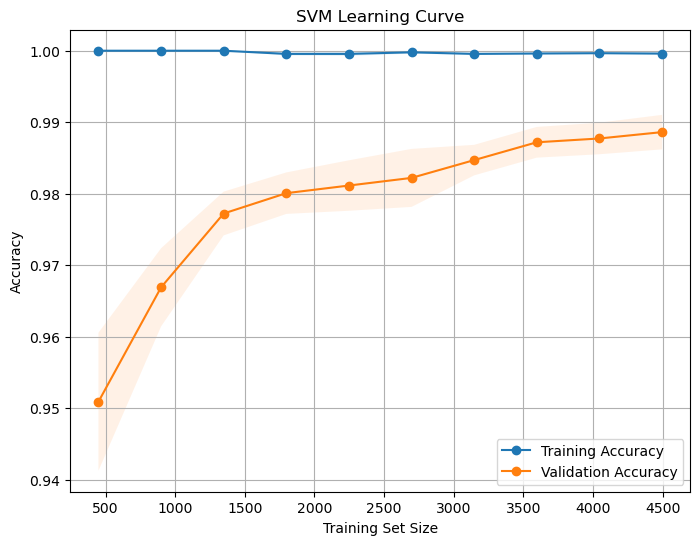

In [658]:
# Implement Support Vector Machines (SVM)
# Define the pipeline for SVM with scaling
svm_pipeline = Pipeline([('scaler', StandardScaler()), ('clf', SVC())])

# Define the hyperparameter grid
svm_param_grid = [
    {'clf__kernel': ['rbf'], 'clf__C': [3, 5, 7], 'clf__gamma': [0.001, 0.01, 0.1]}
]

# Perform nested cross-validation
svm_mean_scores, svm_std_scores, svm_cm = nested_cv(X_final, y, svm_pipeline, svm_param_grid, outer_cv, inner_cv)

# Print results
print("SVM Results:")
for metric in svm_mean_scores:
    print(f"{metric.capitalize()}: {svm_mean_scores[metric]:.4f} (±{svm_std_scores[metric]:.4f})")
print("Overall Confusion Matrix:\n", svm_cm)

# Plot the learning curves
svm_grid_search = GridSearchCV(svm_pipeline, svm_param_grid, cv=inner_cv, scoring='accuracy')
svm_grid_search.fit(X_final, y)
best_svm_pipeline = svm_grid_search.best_estimator_

print("Best SVM Parameters:", svm_grid_search.best_params_)
plot_learning_curve(best_svm_pipeline, X_final, y, train_sizes, outer_cv, 'SVM Learning Curve')

Decision Trees Results:
Accuracy: 0.8993 (±0.0085)
Precision: 0.8996 (±0.0091)
Recall: 0.8991 (±0.0090)
F1: 0.8987 (±0.0093)
Overall Confusion Matrix:
 [[543.   0.   2.   2.   2.   0.   1.   1.   3.   0.]
 [  1. 513.   9.   6.   5.   4.   4.   4.  22.   3.]
 [  1.   3. 511.  12.   0.   3.   4.   2.  16.   5.]
 [  2.   6.  17. 502.   0.  13.   2.   4.   9.  17.]
 [  6.   9.   3.   0. 530.   4.   4.   3.   1.   8.]
 [  2.   5.   2.   7.   6. 510.   1.   5.   6.  14.]
 [  4.  10.   3.   1.   8.   3. 519.   0.  10.   0.]
 [  1.   5.   3.  15.   5.   5.   0. 521.   3.   8.]
 [  4.  22.  17.  20.   7.  11.   6.   7. 452.   8.]
 [  2.  18.   6.  26.  14.  14.   3.  18.   8. 453.]]
Best Decision Tree Parameters: {'clf__max_depth': 15, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 3}


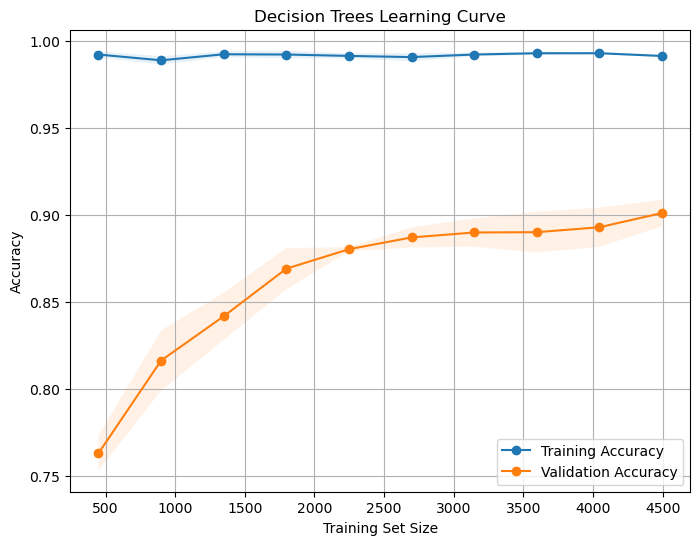

In [686]:
# Implement Decision Trees
# Define the pipeline for Decision Trees
dt_pipeline = Pipeline([('clf', DecisionTreeClassifier())])

# Define the hyperparameter grid
dt_param_grid = {
    'clf__max_depth': [10, 15, 20],
    'clf__min_samples_split': [2, 3, 4],
    'clf__min_samples_leaf': [1, 2, 3]
}

# Perform nested cross-validation
dt_mean_scores, dt_std_scores, dt_cm = nested_cv(X_final, y, dt_pipeline, dt_param_grid, outer_cv, inner_cv)

# Print results
print("Decision Trees Results:")
for metric in dt_mean_scores:
    print(f"{metric.capitalize()}: {dt_mean_scores[metric]:.4f} (±{dt_std_scores[metric]:.4f})")
print("Overall Confusion Matrix:\n", dt_cm)

# Plot the learning curves
dt_grid_search = GridSearchCV(dt_pipeline, dt_param_grid, cv=inner_cv, scoring='accuracy')
dt_grid_search.fit(X_final, y)
best_dt_pipeline = dt_grid_search.best_estimator_

print("Best Decision Tree Parameters:", dt_grid_search.best_params_)
plot_learning_curve(best_dt_pipeline, X_final, y, train_sizes, outer_cv, 'Decision Trees Learning Curve')